In [70]:
# # De bai 2 - Phan tich churn khach hang ngan hang

# Muc tieu:
# - Lam sach du lieu (missing, duplicate theo CustomerId, outlier Age/Balance).
# - Tao bien moi: `AgeGroup`, `BalanceCategory`.
# - Phan tich churn theo Geography, Gender, NumOfProducts, Tenure.
# - Truc quan hoa cac pattern quan trong va xay dung model du doan churn.
# - Xuat file da xu ly de su dung tren Power BI.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
file_path = "/content/Bank-Customer-churn.csv"

df_raw = pd.read_csv(file_path)
print("Shape ban dau:", df_raw.shape)
print("So gia tri missing:", int(df_raw.isna().sum().sum()))

Shape ban dau: (10000, 18)
So gia tri missing: 0


In [73]:
df_raw.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [74]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [75]:
# 1. Loại bỏ trùng lặp dựa trên CustomerId
df_cleaned = df_raw.drop_duplicates(subset=['CustomerId']).copy()

In [84]:
# 2. Xử lý Outliers cho Age và Balance bằng phương pháp IQR (để đồ thị không bị méo)
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Chặn trên/dưới các giá trị vượt ngưỡng
    df[column] = np.clip(df[column], lower, upper)
    return df

df_cleaned = handle_outliers(df_cleaned, 'Age')
df_cleaned = handle_outliers(df_cleaned, 'Balance')

In [85]:
# 3. Tạo Feature Engineering
# Chia nhóm tuổi
df_cleaned['Age Group'] = pd.cut(df_cleaned['Age'],
                                bins=[0, 30, 45, 60, 100],
                                labels=['Young', 'Middle-Aged', 'Senior', 'Elderly'])

# Chia nhóm số dư
df_cleaned['Balance Category'] = pd.cut(df_cleaned['Balance'],
                                       bins=[-1, 50000, 100000, float('inf')],
                                       labels=['Low', 'Medium', 'High'])

print("Làm sạch và tạo cột mới hoàn tất!")

Làm sạch và tạo cột mới hoàn tất!


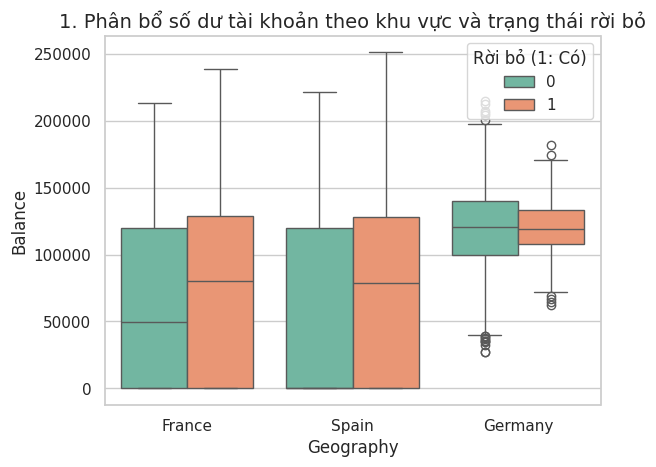

In [91]:
#Biểu đồ Boxplot (Balance theo Quốc gia)
#Soi Outliers và phân bổ tiền của khách hàng
sns.boxplot(data=df_cleaned, x='Geography', y='Balance', hue='Exited', palette='Set2')
plt.title('1. Phân bổ số dư tài khoản theo khu vực và trạng thái rời bỏ', fontsize=14)
plt.legend(title='Rời bỏ (1: Có)', loc='upper right')
plt.show()

In [92]:
total_churn = df_cleaned[df_cleaned['Exited'] == 1].shape[0]
churn_rate = (total_churn / df_cleaned.shape[0]) * 100
top_geography = df_cleaned.groupby('Geography')['Exited'].mean().idxmax()

print(f"--- GHI CHÚ INSIGHT ---")
print(f"- Tổng khách hàng rời bỏ: {total_churn}")
print(f"- Tỷ lệ Churn trung bình: {churn_rate:.2f}%")
print(f"- Khu vực cần chú ý nhất: {top_geography}")

--- GHI CHÚ INSIGHT ---
- Tổng khách hàng rời bỏ: 2038
- Tỷ lệ Churn trung bình: 20.38%
- Khu vực cần chú ý nhất: Germany


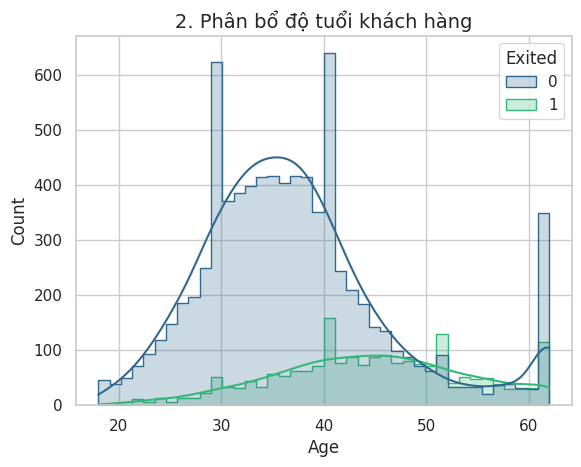

In [93]:
# Biểu đồ Histogram (Độ tuổi), Tìm xem độ tuổi nào là "vùng nguy hiểm" dễ rời bỏ nhất
sns.histplot(data=df_cleaned, x='Age', hue='Exited', kde=True, element="step", palette='viridis')
plt.title('2. Phân bổ độ tuổi khách hàng', fontsize=14)
plt.show()

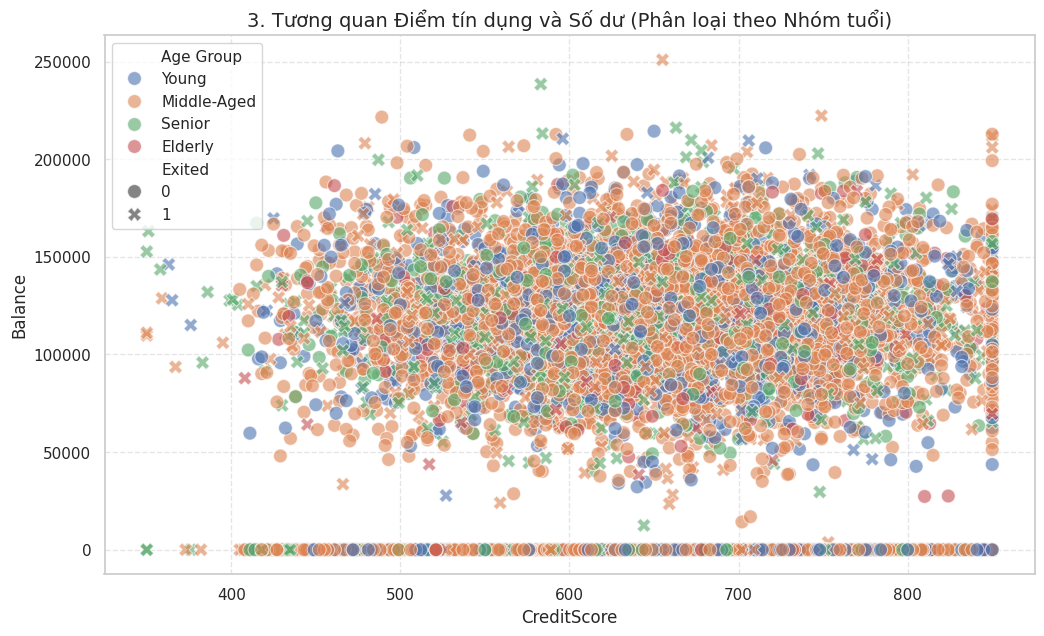

In [95]:
#Biểu đồ Scatter Plot (Credit Score vs Balance), Xem mối liên hệ giữa điểm tín dụng và số tiền trong tài khoản
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_cleaned, x='CreditScore', y='Balance', hue='Age Group', style='Exited', alpha=0.6, s=100)
plt.title('3. Tương quan Điểm tín dụng và Số dư (Phân loại theo Nhóm tuổi)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

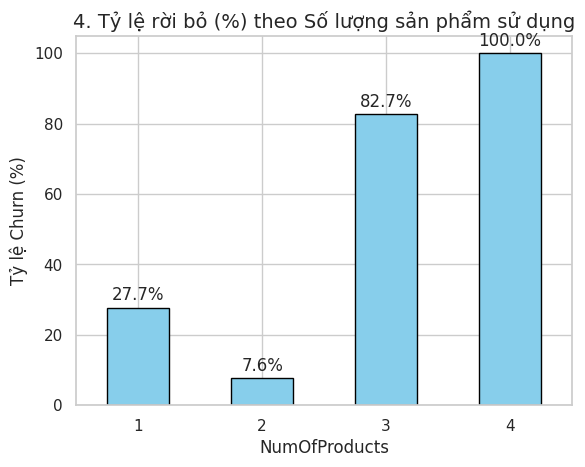

In [98]:
# Biểu đồ Bar Chart (Số lượng sản phẩm), Kiểm tra giả thuyết khách hàng dùng nhiều sản phẩm thì ít rời bỏ
churn_rate_prod = df_cleaned.groupby('NumOfProducts')['Exited'].mean() * 100
ax = churn_rate_prod.plot(kind='bar', color='skyblue', edgecolor='black')

# Thêm con số % trên đầu cột cho rõ
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.title('4. Tỷ lệ rời bỏ (%) theo Số lượng sản phẩm sử dụng', fontsize=14)
plt.ylabel('Tỷ lệ Churn (%)')
plt.xticks(rotation=0)
plt.show()

In [99]:
# Lưu file sạch
df_cleaned.to_csv('Bank_Churn_Final_For_PBI.csv', index=False)

# Tải file về máy tính
from google.colab import files
files.download('Bank_Churn_Final_For_PBI.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Chọn các đặc trưng (Features) quan trọng
features = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
            'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
X = df_cleaned[features].copy()
y = df_cleaned['Exited']

# 2. Mã hóa dữ liệu dạng chữ (Categorical Data)
le = LabelEncoder()
X['Geography'] = le.fit_transform(X['Geography'])
X['Gender'] = le.fit_transform(X['Gender'])

# 3. Chia tập dữ liệu: 80% để học (train), 20% để kiểm tra (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Chuẩn hóa thang đo (Scaling) để mô hình học nhanh hơn
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Đã chuẩn bị xong dữ liệu huấn luyện!")

Đã chuẩn bị xong dữ liệu huấn luyện!


In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Khởi tạo và huấn luyện
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = model.predict(X_test)

print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, y_pred):.2f}")

Độ chính xác (Accuracy): 0.87


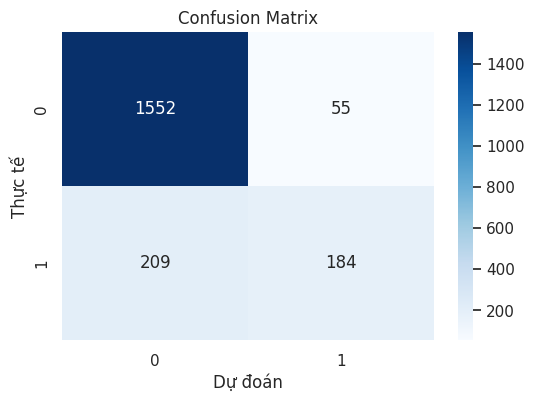

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [102]:
# Vẽ Confusion Matrix để soi lỗi
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix')
plt.show()

# In báo cáo chi tiết (Precision, Recall, F1-score)
print(classification_report(y_test, y_pred))

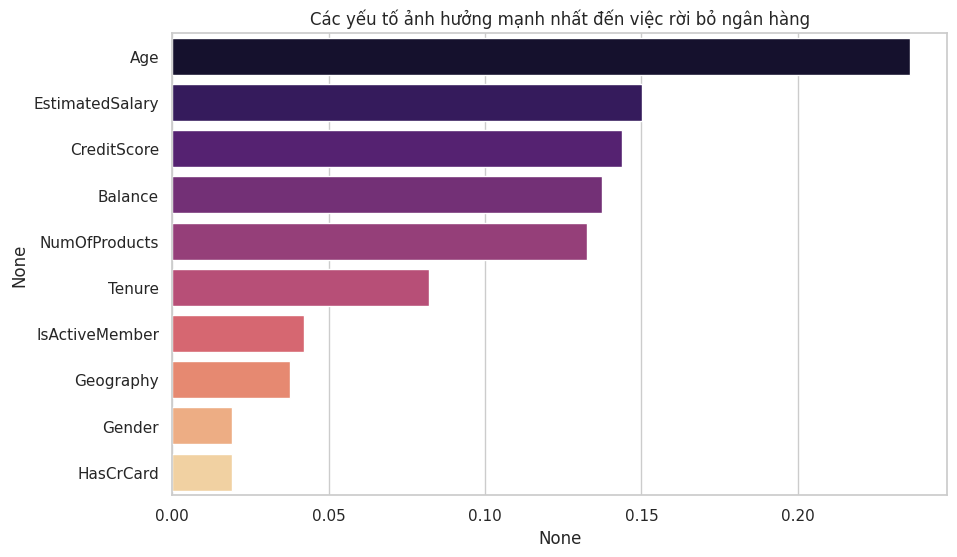

In [103]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=importances.index, palette='magma')
plt.title('Các yếu tố ảnh hưởng mạnh nhất đến việc rời bỏ ngân hàng')
plt.show()